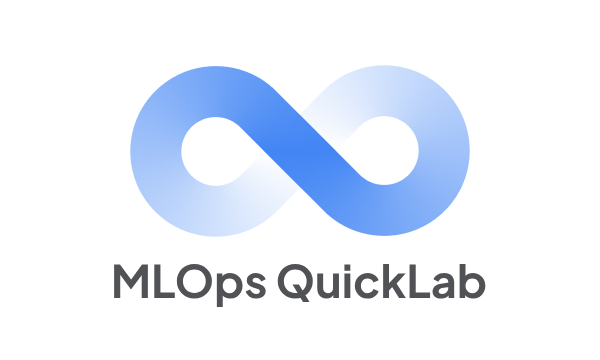

3. PyTorch를 통한 모델 서빙

In [1]:
!pip install datasets torchserve torch-model-archiver torch-workflow-archiver nvgpu

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.8 MB/s eta 0:00:00
  Created wheel for nvgpu: filename=nvgpu-0.10.0-py3-none-any.whl size=9544 sha256=753f5882333db34434cda9225d99a2b1785d33398277e7259585c6d1367cbff0
  Stored in directory: /root/.cache/pip/wheels/6e/4a/5d/db9b77ea9d1981efbe7a03a10318930d6c5897c85f751d52dc
Successfully built nvgpu


In [6]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import DataLoader
from transformers import BatchEncoding, BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.metrics import confusion_matrix
from datasets import load_dataset
from tqdm import tqdm
from typing import TypedDict

In [7]:
dataset = load_dataset("ag_news")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4)
optimizer = AdamW(model.parameters(), lr=5e-5)
criterion = torch.nn.CrossEntropyLoss()

class DatasetItem(TypedDict):
    text: str
    label: str


def preprocess_data(dataset_item: DatasetItem) -> dict[str, torch.Tensor]:
    return tokenizer(dataset_item["text"], truncation=True, padding="max_length", return_tensors="pt")


train_dataset = dataset["train"].select(range(1200)).map(preprocess_data, batched=True)
test_dataset = dataset["test"].select(range(800)).map(preprocess_data, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

...

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

num_epochs = 3
losses: list[float] = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}"):
        inputs = {key: batch[key].to(device) for key in batch}
        labels = inputs.pop("label")
        outputs = model(**inputs, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    average_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}, Average Loss: {average_loss}")

Epoch 1: 100%|██████████| 150/150 [01:47<00:00,  1.40it/s]


Epoch 1, Average Loss: 0.6457971408466499


Epoch 2: 100%|██████████| 150/150 [01:53<00:00,  1.33it/s]


Epoch 2, Average Loss: 0.28761011827737093


Epoch 3: 100%|██████████| 150/150 [01:52<00:00,  1.33it/s]

Epoch 3, Average Loss: 0.14956834288313986


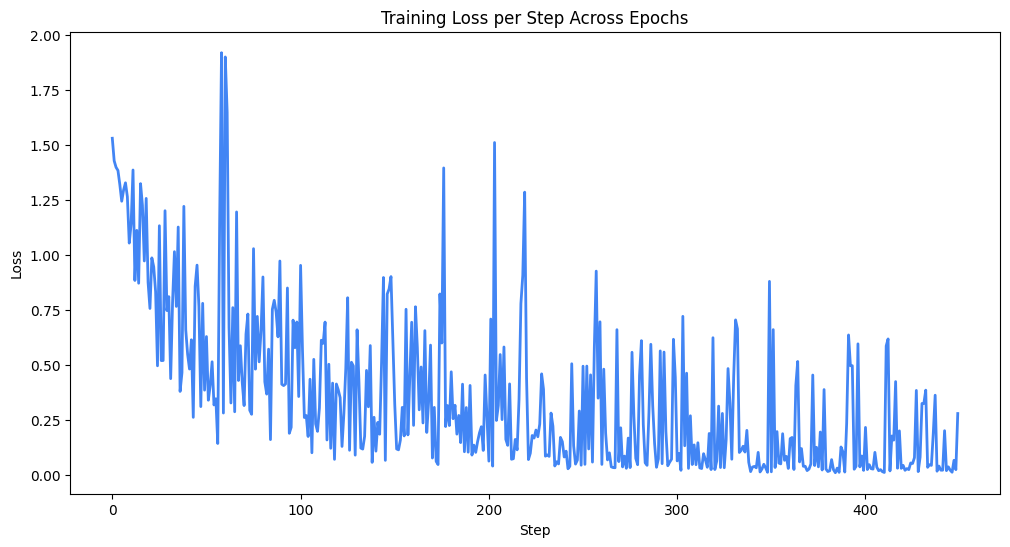

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(losses, color="#4285f4", linewidth=2)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss per Step Across Epochs")
plt.show()

## 모델 평가

In [10]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        inputs = {key: batch[key].to(device) for key in batch}
        labels = inputs.pop("label")
        outputs = model(**inputs, labels=labels)
        logits = outputs.logits
        predicted_labels = torch.argmax(logits, dim=1)
        correct += (predicted_labels == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total

print("")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Evaluating: 100%|██████████| 100/100 [00:24<00:00,  4.02it/s]


Test Accuracy: 81.75%


In [11]:
test_input = "[Official] 'Legendary Coach Resigns → Appoints New Commander' Suwon Completes Coaching Staff... Scout Bae Ki-jong Joins + Coach Shin Hwa-yong Remains"
test_input_processed = tokenizer(test_input, truncation=True, padding="max_length", return_tensors="pt").to(device)
logits = model(**test_input_processed).logits
print(logits)
predicted_labels = torch.argmax(logits, dim=1)

labeling_mapper = ["world", "sports", "business", "sci/tech"]
print(labeling_mapper[predicted_labels[0]])

tensor([[ 3.8059, -0.2593, -1.5900, -1.5619]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
world


In [12]:
all_predictions: list[int] = []
all_labels: list[int] = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        inputs = {key: batch[key].to(device) for key in batch}
        labels = inputs.pop("label")
        outputs = model(**inputs)
        logits = outputs.logits
        predicted_labels = torch.argmax(logits, dim=1)

        all_predictions.extend(predicted_labels.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

Evaluating: 100%|██████████| 100/100 [00:23<00:00,  4.25it/s]


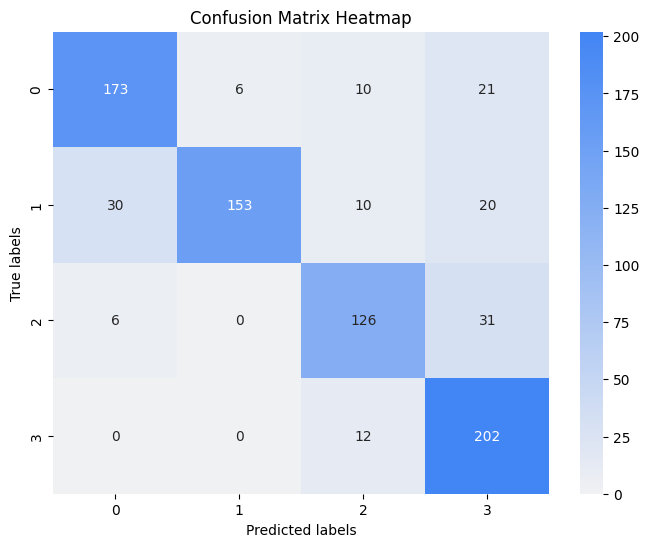

In [13]:
conf_matrix = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="g", cmap=sns.light_palette("#4285f4", as_cmap=True))
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix Heatmap")
plt.show()

## 모델 서빙

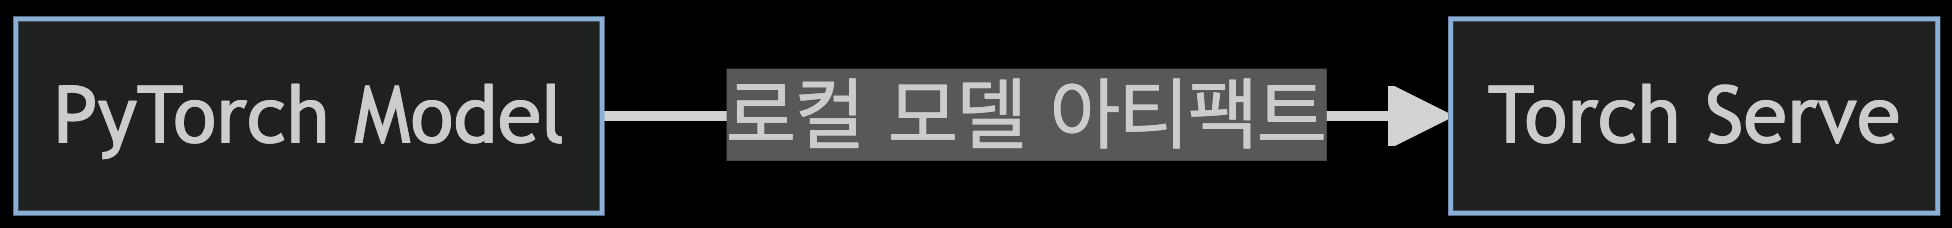


In [14]:
# 모델 체크포인트 저장.
model_save_path = "bert_news_classification_model.pth"
torch.save(model.state_dict(), model_save_path)

In [15]:
%%writefile model_handler.py
import json

import torch
from ts.context import Context
from ts.torch_handler.base_handler import BaseHandler
from transformers import BatchEncoding, BertTokenizer, BertForSequenceClassification

class ModelHandler(BaseHandler):
    def __init__(self):
        self.initialized = False
        self.tokenizer = None
        self.model = None

    def initialize(self, context: Context):
        self.initialized = True
        self.tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
        self.model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4)
        self.model.load_state_dict(torch.load("bert_news_classification_model.pth"))
        self.model.to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
        self.model.eval()

    def preprocess(self, data: list[dict[str, bytearray]]) -> BatchEncoding:
        model_input_texts: list[str] = sum([json.loads(item.get("body").decode("utf-8"))["data"] for item in data], [])
        inputs = self.tokenizer(model_input_texts, truncation=True, padding=True, max_length=512, return_tensors="pt")
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        return inputs.to(device)

    def inference(self, input_batch: BatchEncoding) -> torch.Tensor:
        with torch.no_grad():
            outputs = self.model(**input_batch)
            return outputs.logits

    def postprocess(self, inference_output: torch.Tensor) -> list[dict[str, float]]:
        probabilities = torch.nn.functional.softmax(inference_output, dim=1)
        return [{"label": int(torch.argmax(prob)), "probability": float(prob.max())} for prob in probabilities]

Writing model_handler.py


In [16]:
%%writefile config.properties
inference_address=http://0.0.0.0:5000
management_address=http://0.0.0.0:5001
metrics_address=http://0.0.0.0:5002

Writing config.properties


In [17]:
# bert vocab 파일 (아티팩트)

!wget https://raw.githubusercontent.com/microsoft/SDNet/master/bert_vocab_files/bert-base-uncased-vocab.txt \
    -O bert-base-uncased-vocab.txt

--2026-04-14 06:18:41--  https://raw.githubusercontent.com/microsoft/SDNet/master/bert_vocab_files/bert-base-uncased-vocab.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 231508 (226K) [text/plain]
Saving to: ‘bert-base-uncased-vocab.txt’

bert-base-uncased-v 100%[===================>] 226.08K  --.-KB/s    in 0.009s  

2026-04-14 06:18:41 (23.3 MB/s) - ‘bert-base-uncased-vocab.txt’ saved [231508/231508]



In [18]:
# Torch serve archiver의 최종 파일 저장 위치.
# .mar 확장자 파일을 생성하여 패키징 하게 된다.

!mkdir -p model-store

In [19]:
!torch-model-archiver \
    --model-name bert_news_classification \
    --version 1.0 \
    --serialized-file bert_news_classification_model.pth \
    --handler ./model_handler.py \
    --extra-files "bert-base-uncased-vocab.txt" \
    --export-path model-store \
    -f

In [1]:
!python --version

Python 3.12.13


In [1]:
%%script bash --bg
# 서버를 백그라운드에서 실행

# PYTHONPATH=/usr/lib/python3.10 torchserve \
torchserve \
    --start \
    --ncs \
    --ts-config config.properties \
    --model-store model-store \
    --models bert_news_classification=bert_news_classification.mar \
    --disable-token-auth > torchserve_log.log

In [13]:
# 1. 혹시 남아있을지 모르는 기존 프로세스 강제 종료
!fuser -k 5000/tcp
!torchserve --stop

5000/tcp:            24262
Removing orphan pid file.
TorchServe is not currently running.


In [17]:
import subprocess
import os

# 2. TorchServe 실행 (로그를 직접 확인하기 위해 stdout 설정)
with open("torchserve_log.log", "w") as f:
    process = subprocess.Popen(
        ["torchserve", "--start", "--ncs", "--ts-config", "config.properties",
         "--model-store", "model-store",
         "--models", "bert_news_classification=bert_news_classification.mar", "--disable-token-auth"],
        stdout=f,
        stderr=f,
        preexec_fn=os.setpgrp # 프로세스 그룹을 분리하여 셀 종료 시에도 유지 시도
    )

print("서버 실행 중... 10초 대기 후 포트 상태를 확인합니다.")
import time
time.sleep(10)

# 3. 포트 상태 재확인
!netstat -lntp | grep 5000

서버 실행 중... 10초 대기 후 포트 상태를 확인합니다.
tcp6       0      0 :::5000                 :::*                    LISTEN      25138/java          


In [52]:
# !pip uninstall -y pynvml
# !pip install nvidia-ml-py

Found existing installation: pynvml 13.0.1
Uninstalling pynvml-13.0.1:
  Successfully uninstalled pynvml-13.0.1


In [2]:
# !tail -n 100 -f torchserve_log.log

Removing orphan pid file.
2026-04-14T06:44:49,525 [DEBUG] main org.pytorch.serve.util.ConfigManager - xpu-smi not available or failed: Cannot run program "xpu-smi": error=2, No such file or directory
2026-04-14T06:44:49,551 [WARN ] main org.pytorch.serve.util.ConfigManager - Your torchserve instance can access any URL to load models. When deploying to production, make sure to limit the set of allowed_urls in config.properties
2026-04-14T06:44:49,586 [INFO ] main org.pytorch.serve.servingsdk.impl.PluginsManager - Initializing plugins manager...
2026-04-14T06:44:49,771 [INFO ] main org.pytorch.serve.metrics.configuration.MetricConfiguration - Successfully loaded metrics configuration from /usr/local/lib/python3.12/dist-packages/ts/configs/metrics.yaml
2026-04-14T06:44:49,925 [INFO ] main org.pytorch.serve.ModelServer - 
Torchserve version: 0.12.0
TS Home: /usr/local/lib/python3.12/dist-packages
Current directory: /content
Temp directory: /tmp
Metrics config path: /usr/local/lib/python3.1

In [12]:
# 아래와 같이 뜨면 정상 실행.
# {
#   "status": "Healthy"
# }

!curl -X GET localhost:5000/ping

{
  "status": "Healthy"
}


In [5]:
!netstat -lntp | grep 5000

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
%%shell

# 모델 실제 평가를 위해 외부 뉴스 기사 데이터 셋 파일 생성.

cat > request_sports.json <<EOF
{
  "data": [
    "Bleary-eyed from 16 hours on a Greyhound bus, he strolled into the stadium running on fumes. He’d barely slept in two days. The ride he was supposed to hitch from Charlotte to Indianapolis canceled at the last minute, and for a few nervy hours, Antonio Barnes started to have his doubts. The trip he’d waited 40 years for looked like it wasn’t going to happen.ADVERTISEMENTBut as he moved through the concourse at Lucas Oil Stadium an hour before the Colts faced the Raiders, it started to sink in. His pace quickened. His eyes widened. His voice picked up.“I got chills right now,” he said. “Chills.”Barnes, 57, is a lifer, a Colts fan since the Baltimore days. He wore No. 25 on his pee wee football team because that’s the number Nesby Glasgow wore on Sundays. He was a talent in his own right, too: one of his old coaches nicknamed him “Bird” because of his speed with the ball.Back then, he’d catch the city bus to Memorial Stadium, buy a bleacher ticket for $5 and watch Glasgow and Bert Jones, Curtis Dickey and Glenn Doughty. When he didn’t have any money, he’d find a hole in the fence and sneak in. After the game was over, he’d weasel his way onto the field and try to meet the players. “They were tall as trees,” he remembers.He remembers the last game he went to: Sept. 25, 1983, an overtime win over the Bears. Six months later the Colts would ditch Baltimore in the middle of the night, a sucker-punch some in the city never got over. But Barnes couldn’t quit them. When his entire family became Ravens fans, he refused. “The Colts are all I know,” he says.For years, when he couldn’t watch the games, he’d try the radio. And when that didn’t work, he’d follow the scroll at the bottom of a screen.“There were so many nights I’d just sit there in my cell, picturing what it’d be like to go to another game,” he says. “But you’re left with that thought that keeps running through your mind: I’m never getting out.”It’s hard to dream when you’re serving a life sentence for conspiracy to commit murder.It started with a handoff, a low-level dealer named Mickey Poole telling him to tuck a Ziploc full of heroin into his pocket and hide behind the Murphy towers. This was how young drug runners were groomed in Baltimore in the late 1970s. This was Barnes’ way in.ADVERTISEMENTHe was 12.Back then he idolized the Mickey Pooles of the world, the older kids who drove the shiny cars, wore the flashy jewelry, had the girls on their arms and made any working stiff punching a clock from 9 to 5 look like a fool. They owned the streets. Barnes wanted to own them, too.“In our world,” says his nephew Demon Brown, “the only successful people we saw were selling drugs and carrying guns.”So whenever Mickey would signal for a vial or two, Barnes would hurry over from his hiding spot with that Ziploc bag, out of breath because he’d been running so hard."
  ]
}
EOF

cat > request_business.json <<EOF
{
  "data": [
    "DETROIT – America maintained its love affair with pickup trucks in 2023 — but a top-selling vehicle from Toyota Motor nearly ruined their tailgate party.Sales of the Toyota RAV4 compact crossover came within 10,000 units of Stellantis’ Ram pickup truck last year, a near-No. 3 ranking that would have marked the first time since 2014 that a non-pickup claimed one of the top three U.S. sales podium positions.The RAV4 has rapidly closed the gap: In 2020, the vehicle undersold the Ram truck by more than 133,000 units. Last year, it lagged by just 9,983. Stellantis sold 444,926 Ram pickups last year, a 5% decline from 2022.“Trucks are always at the top because they’re bought by not only individuals, but also fleet buyers and we saw heavy fleet buying last year,” said Michelle Krebs, an executive analyst at Cox Automotive. “The RAV4 shows that people want affordable, smaller SUVs, and the fact that there’s also a hybrid version of that makes it popular with people.”"
  ]
}
EOF

cat > request_sci_tech.json <<EOF
{
  "data": [
    "OpenVoice comprises two AI models working together for text-to-speech conversion and voice tone cloning.The first model handles language style, accents, emotion, and other speech patterns. It was trained on 30,000 audio samples with varying emotions from English, Chinese, and Japanese speakers. The second “tone converter” model learned from over 300,000 samples encompassing 20,000 voices.By combining the universal speech model with a user-provided voice sample, OpenVoice can clone voices with very little data. This helps it generate cloned speech significantly faster than alternatives like Meta’s Voicebox.Californian startup OpenVoice comes from California-based startup MyShell, founded in 2023. With $5.6 million in early funding and over 400,000 users already, MyShell bills itself as a decentralised platform for creating and discovering AI apps.  In addition to pioneering instant voice cloning, MyShell offers original text-based chatbot personalities, meme generators, user-created text RPGs, and more. Some content is locked behind a subscription fee. The company also charges bot creators to promote their bots on its platform.By open-sourcing its voice cloning capabilities through HuggingFace while monetising its broader app ecosystem, MyShell stands to increase users across both while advancing an open model of AI development."
  ]
}
EOF


In [19]:
# 스포츠 기사 평가 (레이블: 1)
!curl -X POST \
    -H "Accept: application/json" \
    -T "request_sports.json" \
    http://localhost:5000/predictions/bert_news_classification

{
  "label": 1,
  "probability": 0.9749694466590881
}

In [20]:
# 비즈니스 기사 평가 (레이블: 2)
!curl -X POST \
    -H "Accept: application/json" \
    -T "request_business.json" \
    http://localhost:5000/predictions/bert_news_classification

{
  "label": 3,
  "probability": 0.5819491147994995
}

In [21]:
# 테크 기사 평가 (레이블: 3)
!curl -X POST \
    -H "Accept: application/json" \
    -T "request_sci_tech.json" \
    http://localhost:5000/predictions/bert_news_classification

{
  "label": 3,
  "probability": 0.9749202728271484
}

## ngrok을 통한 외부 연결

ngrok은 로컬에 서비스되는 데몬/서버에 외부 도메인을 연결시켜,
외부에서 접근하기 쉽도록 만들어주는 서비스입니다.

5000번으로 호스팅한 서빙 서버 접근을 위해 아래 코드에서는 ngrok을 연결합니다.

In [ ]:
!pip install pyngrok

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("2aT0pKF7B5b3u8cQbsDoj12qdZs_52zPrJtqRW9dAGC3w6VFW")
inference_tunnel = ngrok.connect("5000")
inference_tunnel

<NgrokTunnel: "https://8cfa-35-237-176-64.ngrok-free.app" -> "http://localhost:5000">

In [ ]:
!curl -X POST \
    -H "Accept: application/json" \
    -T "request_sci_tech.json" \
    https://1c1d-34-29-238-199.ngrok-free.app/predictions/bert_news_classification

Tunnel 1c1d-34-29-238-199.ngrok-free.app not found

ERR_NGROK_3200
